In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD

# 1. Raw Data Loading
ozone = pd.read_csv('/content/ozone.csv')

df = ozone[['Temp', 'Ozone']]

# 2. 데이터 전처리 진행
# 여기서는 결치값만 삭제하고 넘어갈꺼예요!
new_df = df.dropna(how='any', inplace=False)

# 3. 학습데이터를 분리
x_data = new_df['Temp'].values.reshape(-1,1)
t_data = new_df['Ozone'].values.reshape(-1,1)

# 4. Model 구현
keras_model = Sequential()

input_layer = Flatten(input_shape=(1,))
output_layer = Dense(units=1,
                     activation='linear')

keras_model.add(input_layer)
keras_model.add(output_layer)

# 만들어진 모델에 대한 설정을 해요!
keras_model.compile(optimizer=SGD(learning_rate=1e-4),
                    loss='mse')

# 5. 모델 학습
keras_model.fit(x_data,
                t_data,
                epochs=1000,
                verbose=1)



In [6]:
# 모델 구현이 끝났으니 이제 prediction(예측)을 해보아요!
keras_result = keras_model.predict(np.array([[62]]))
print(keras_result)  # [[44.000343]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
[[44.000343]]


In [ ]:
# sklearn을 이용해서 모델 학습을 시킨 후
# 모델 그림을 그려서 tensorflow와 비교해 볼꺼예요!
from sklearn import linear_model

# model 구현
sklearn_model = linear_model.LinearRegression()
sklearn_model.fit(x_data,
                  t_data)


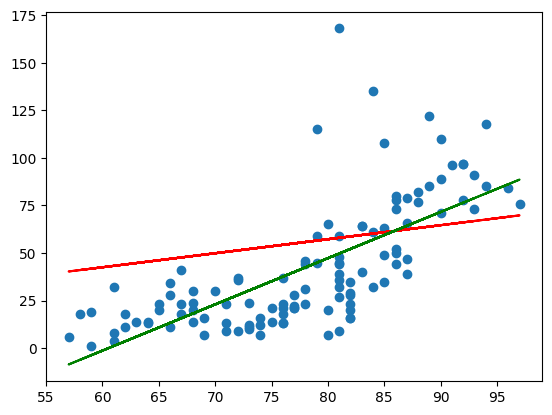

In [12]:
# 그림을 그려서 우리 모델이 잘 작성되었는지 확인!
plt.scatter(x_data.ravel(),
            t_data.ravel())
# 우리 keras 모델에서 구한 W와 b값을 이용해서 모델(직선)을
# 추가적으로 그려보아요!
keras_weight, keras_bias = output_layer.get_weights()
plt.plot(x_data.ravel(),
         x_data.ravel() * keras_weight.ravel() + keras_bias,
         color='r')

# sklearn으로 모델을 구한 후 그림을 그려요!
plt.plot(x_data.ravel(),
         x_data.ravel() *  sklearn_model.coef_.ravel() +
         sklearn_model.intercept_.ravel(),
         color='g')
plt.show()

In [ ]:
# sklearn 구현(정답과 가장 가까워요!)
# Tensorflow 구현
# python 직접 구현

# Tensorflow구현과 python 직접 구현은 정답과 약간 거리가 있어요!
# 가장 큰 이유는 데이터 전처리에 있어요!

# 결측치 처리
# 이상치 처리
# 정규화 처리(이상치에 영향을 받아요!)

8.0
4.5
11.5
22.0 -6.0


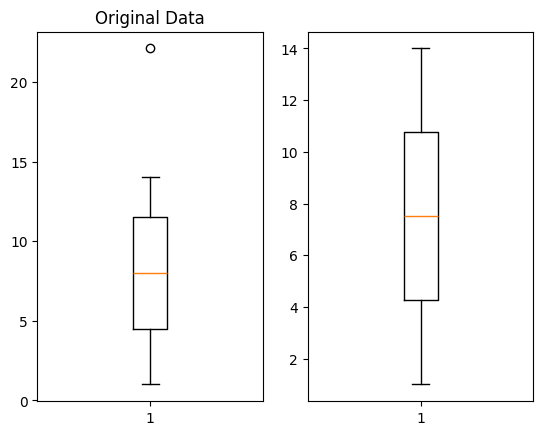

In [24]:
# Tukey's Fence방식으로 이상치를 판별해 보아요!
import matplotlib.pyplot as plt
import numpy as np

data = np.array([1,2,3,4,5,6,7,8,9,10,11,12,13,14,22.1])

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.set_title('Original Data')
ax1.boxplot(data)

# numpy를 이용하면 사분위값을 아주 쉽게 구할 수 있어요!
print(np.median(data))  # 8.0
print(np.percentile(data,25)) # 4.5
print(np.percentile(data,75)) # 11.5

# IQR value
iqr_value = np.percentile(data,75) - np.percentile(data,25)

# upper_fence
upper_fence = np.percentile(data,75) + (iqr_value * 1.5)
# lower_fence
lower_fence = np.percentile(data,25) - (iqr_value * 1.5)
print(upper_fence, lower_fence)  # 22.0 -6.0

# 내가 가지고 있는 데이터에서 이상치만 출력해보세요!
# data[(data > upper_fence) | (data < lower_fence)]

result_data = data[(data <= upper_fence) & (data >= lower_fence)]
# print(result_data)
ax2.boxplot(result_data)
plt.show()

75.0 25.0


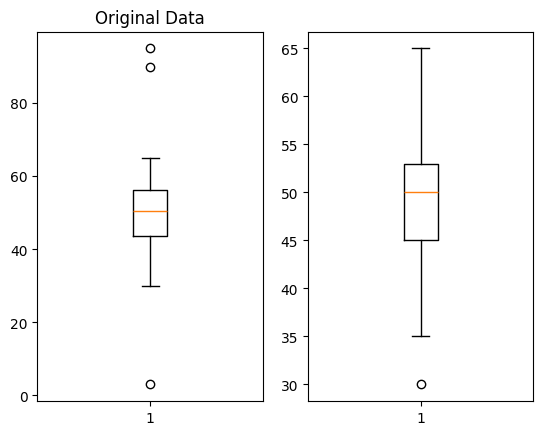

In [27]:
# 데이터를 다르게해서 먼저 Tukey's Fence로
# 이상치를 찾아보아요!
import numpy as np
import pandas as pd

data = np.array([3,30,35,40,45,48,49,50,51,52,53,55,60,65,90,95])

fig = plt.figure()
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.set_title('Original Data')
ax1.boxplot(data)

# IQR value
iqr_value = np.percentile(data,75) - np.percentile(data,25)

# upper_fence
upper_fence = np.percentile(data,75) + (iqr_value * 1.5)
# lower_fence
lower_fence = np.percentile(data,25) - (iqr_value * 1.5)
print(upper_fence, lower_fence)  # 75.0 25.0

result_data = data[(data <= upper_fence) & (data >= lower_fence)]
ax2.boxplot(result_data)
plt.show()

In [35]:
# 같은 데이터를 Z-Score를 이용하는 방법으로
# 이상치 처리를 해 볼꺼예요!
from scipy import stats

data = np.array([3,30,35,40,45,48,49,50,51,52,53,55,60,65,90,95])

zscore_threshold = 2.0

print(data[~(np.abs(stats.zscore(data)) > zscore_threshold)])

[30 35 40 45 48 49 50 51 52 53 55 60 65 90]


In [36]:
# 온도에 따른 오존량에 따른 데이터에 대해
# 이상치 처리를 한 후
# Tensorflow와 sklearn으로 Simple Liear Regression을
# 구현해서 62도에 대한 예측 오존값을 구해보세요!
# 그리고 수정된 데이터로 그래프도 그려서 확인해보세요!

In [59]:
%reset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn import linear_model
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [60]:
# 1. Raw Data Loading
ozone = pd.read_csv('/content/ozone.csv')

df = ozone[['Temp', 'Ozone']]

# 2. 데이터 전처리 진행

# 2-1. 결치값 처리(삭제)
new_df = df.dropna(how='any', inplace=False)
# 2-2. 이상치 처리(삭제)
# 먼저 이상치가 있는지 확인!
zscore_threshold = 2.0

mask = ~(np.abs(stats.zscore(new_df['Ozone'].values)) > zscore_threshold)

df1 = new_df.loc[mask,:]
# 3. 정규화 처리
scaler_x = MinMaxScaler()  # 정규화를 진행시킬 수 있는 능력을 가진 객체
scaler_t = MinMaxScaler()

scaler_x.fit(df1['Temp'].values.reshape(-1,1))
scaler_t.fit(df1['Ozone'].values.reshape(-1,1))


MinMaxScaler()

In [61]:
# 3. 학습데이터를 분리
x_data = df1['Temp'].values.reshape(-1,1)
t_data = df1['Ozone'].values.reshape(-1,1)

# 3-1. 분리된 데이터를 정규화 진행
x_data_norm = scaler_x.transform(x_data)
t_data_norm = scaler_t.transform(t_data)


In [ ]:
# 4. Model 구현
# 4-1. Tensorflow Model 구현
keras_model = Sequential()

input_layer = Flatten(input_shape=(1,))
output_layer = Dense(units=1,
                     activation='linear')

keras_model.add(input_layer)
keras_model.add(output_layer)

# 만들어진 모델에 대한 설정을 해요!
keras_model.compile(optimizer=SGD(learning_rate=1e-2),
                    loss='mse')

# 5. 모델 학습
keras_model.fit(x_data_norm,
                t_data_norm,
                epochs=1000,
                verbose=1)

# 4-2. sklearn Model 구현
sklearn_model = linear_model.LinearRegression()
sklearn_model.fit(x_data,
                  t_data)

In [ ]:
# 5. Model 검증
# 이건 나중에 검증방법을 배운 후 진행할꺼예요!

In [63]:
# 6. Prediction(예측)
my_data = np.array([[62]])
my_data_norm = scaler_x.transform(my_data)
keras_result_norm = keras_model.predict(my_data_norm)
keras_result = scaler_t.inverse_transform(keras_result_norm)

sklearn_result = sklearn_model.predict(my_data)
print(f'keras_result : {keras_result}') # [[5.5116386]]
print(f'sklearn_result: {sklearn_result}')  # [[4.51299041]]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
keras_result : [[5.616905]]
sklearn_result: [[4.51299041]]


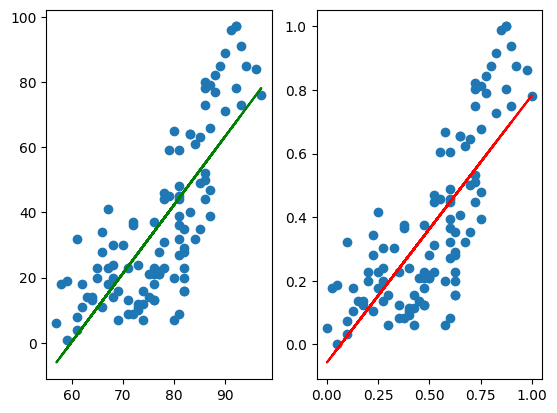

In [64]:
# 구현된 두개의 모델을 그래프로 각각 그려보아요!
fig = plt.figure()

# ax1은 sklearn으로 그리고
# ax2는 tensorflow keras를 이용해서 그려요!
ax1 = fig.add_subplot(1,2,1)
ax2 = fig.add_subplot(1,2,2)

ax1.scatter(x_data.ravel(),
            t_data.ravel())

ax1.plot(x_data.ravel(),
         x_data.ravel() *  sklearn_model.coef_.ravel() +
         sklearn_model.intercept_.ravel(),
         color='g')

ax2.scatter(x_data_norm.ravel(),
            t_data_norm.ravel())
# 우리 keras 모델에서 구한 W와 b값을 이용해서 모델(직선)을
# 추가적으로 그려보아요!
keras_weight, keras_bias = output_layer.get_weights()
ax2.plot(x_data_norm.ravel(),
         x_data_norm.ravel() * keras_weight.ravel() + keras_bias,
         color='r')

plt.show()

In [ ]:
# Multiple Linear Regression을 구현
# Ozone Data를 이용해서 구현
# 독립변수 3개(태양광, 바람, 온도)
# 종속변수 1개(오존)
# 알고싶어요!
# 태양광세기 : 150, 바람 : 10, 온도 : 80일 경우
# 오존량은 얼마일까요?
# sklearn 구현 & Tensorflow Keras 구현
# ==> 40

In [65]:
%reset

Once deleted, variables cannot be recovered. Proceed (y/[n])? y


In [66]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
from sklearn.preprocessing import MinMaxScaler

from sklearn import linear_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.optimizers import SGD

In [71]:
# 1. Raw Data Loading
ozone = pd.read_csv('/content/ozone.csv')
# display(ozone) # 153 rows × 6 columns
# 필요한 컬럼만 남기고 나머지는 컬럼은 삭제
df = ozone[['Solar.R', 'Wind', 'Temp', 'Ozone']]
# display(df.head())

,Ozone,Solar.R,Wind,Temp,Month,Day
0,41.0,190.0,7.4,67,5,1
1,36.0,118.0,8.0,72,5,2
2,12.0,149.0,12.6,74,5,3
3,18.0,313.0,11.5,62,5,4
4,NaN,NaN,14.3,56,5,5
...,...,...,...,...,...,...
148,30.0,193.0,6.9,70,9,26
149,NaN,145.0,13.2,77,9,27
150,14.0,191.0,14.3,75,9,28
151,18.0,131.0,8.0,76,9,29


In [ ]:
# 2. 데이터 전처리
# 2-1. 결측치 처리
new_df = df.dropna(how='any', inplace=False)
# display(new_df) # 111 rows × 4 columns
# 2-2. 이상치 처리
zscore_threshold = 2.0
df1 = new_df.loc[np.abs(stats.zscore(new_df['Ozone'].values)) <= zscore_threshold]
# display(df1) # 105 rows × 4 columns
# 2-3. 정규화 처리
# 먼저 x_data와 t_data를 분리
x_data = df1.drop('Ozone', axis=1, inplace=False).values
t_data = df1['Ozone'].values.reshape(-1,1)

scaler_x = MinMaxScaler()
scaler_t = MinMaxScaler()

scaler_x.fit(x_data)
scaler_t.fit(t_data)

x_data_norm = scaler_x.transform(x_data)
t_data_norm = scaler_t.transform(t_data)
print(x_data_norm)

In [77]:
# 3. Model 구현 & 예측
# 3-1. sklearn을 이용한 모델 구현
sklearn_model = linear_model.LinearRegression()
sklearn_model.fit(x_data, t_data)
sklearn_result = sklearn_model.predict(np.array([[150, 10, 80]]))
print(sklearn_result) # [[40.90068539]]

[[40.90068539]]


In [78]:
# 3-2. Tensorflow Keras를 이용한 모델 구현
keras_model = Sequential()
keras_model.add(Flatten(input_shape=(3,)))
keras_model.add(Dense(units=1,
                      activation='linear'))
keras_model.compile(optimizer=SGD(learning_rate=1e-2),
                    loss='mse')
keras_model.fit(x_data_norm,
                t_data_norm,
                epochs=1000,
                verbose=1)
my_data = np.array([[150, 10, 80]])
my_data_norm = scaler_x.transform(my_data)
keras_result_norm = keras_model.predict(my_data_norm)
keras_result = scaler_t.inverse_transform(keras_result_norm)
print(keras_result) # [[40.28016]]

Epoch 1/1000


/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4529 
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3351 
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2625
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2185 
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2009 
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1719
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.1513 
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1252
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1151 
Epoch 10/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1090
Epoch 11/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1157 
Epoch 12/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0977
Epoch 13/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0974 
Epoch 14/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0962 
Epoch 15/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0916 
Epoch 16/1000
4

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
[[40.28016]]
